In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np

# Cargar dataset
df = pd.read_excel('/content/drive/MyDrive/Proyecto terminal/Datasets/PCOS_data_without_infertility.xlsx', sheet_name='Full_new')

# Ver primeras filas
df.head()

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1,1,0,28,44.6,152.0,19.300000,15,78,22,...,1.0,0,110,80,3,3,18.0,18.0,8.5,NaN
1,2,2,0,36,65.0,161.5,24.921163,15,74,20,...,0.0,0,120,70,3,5,15.0,14.0,3.7,NaN
2,3,3,1,33,68.8,165.0,25.270891,11,72,18,...,1.0,0,120,80,13,15,18.0,20.0,10.0,NaN
3,4,4,0,37,65.0,148.0,29.674945,13,72,20,...,0.0,0,120,70,2,2,15.0,14.0,7.5,NaN
4,5,5,0,25,52.0,161.0,20.060954,11,72,18,...,0.0,0,120,80,3,4,16.0,14.0,7.0,NaN


In [ ]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 45 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Sl. No                  541 non-null    int64  
 1   Patient File No.        541 non-null    int64  
 2   PCOS (Y/N)              541 non-null    int64  
 3    Age (yrs)              541 non-null    int64  
 4   Weight (Kg)             541 non-null    float64
 5   Height(Cm)              541 non-null    float64
 6   BMI                     541 non-null    float64
 7   Blood Group             541 non-null    int64  
 8   Pulse rate(bpm)         541 non-null    int64  
 9   RR (breaths/min)        541 non-null    int64  
 10  Hb(g/dl)                541 non-null    float64
 11  Cycle(R/I)              541 non-null    int64  
 12  Cycle length(days)      541 non-null    int64  
 13  Marraige Status (Yrs)   540 non-null    float64
 14  Pregnant(Y/N)           541 non-null    in

In [ ]:
# Eliminar columnas vacías o irrelevantes
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Eliminar IDs (no sirven para ML)
df = df.drop(columns=['Sl. No', 'Patient File No.'], errors='ignore')

In [ ]:
# Ver valores nulos
df.isnull().sum().sort_values(ascending=False)

,0
Fast food (Y/N),1
Marraige Status (Yrs),1
Weight (Kg),0
Height(Cm),0
BMI,0
Blood Group,0
Pulse rate(bpm),0
RR (breaths/min),0
PCOS (Y/N),0
Age (yrs),0


In [ ]:
# Rellenar numéricas con mediana
for col in df.select_dtypes(include=np.number):
    df[col].fillna(df[col].median(), inplace=True)

# Rellenar categóricas con moda
for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_1435/3692921909.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
/tmp/ipykernel_1435/3692921909.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

In [ ]:
df['PCOS (Y/N)'].value_counts()

,count
PCOS (Y/N),
0,364
1,177


In [ ]:
df = df.replace({'Y': 1, 'N': 0})

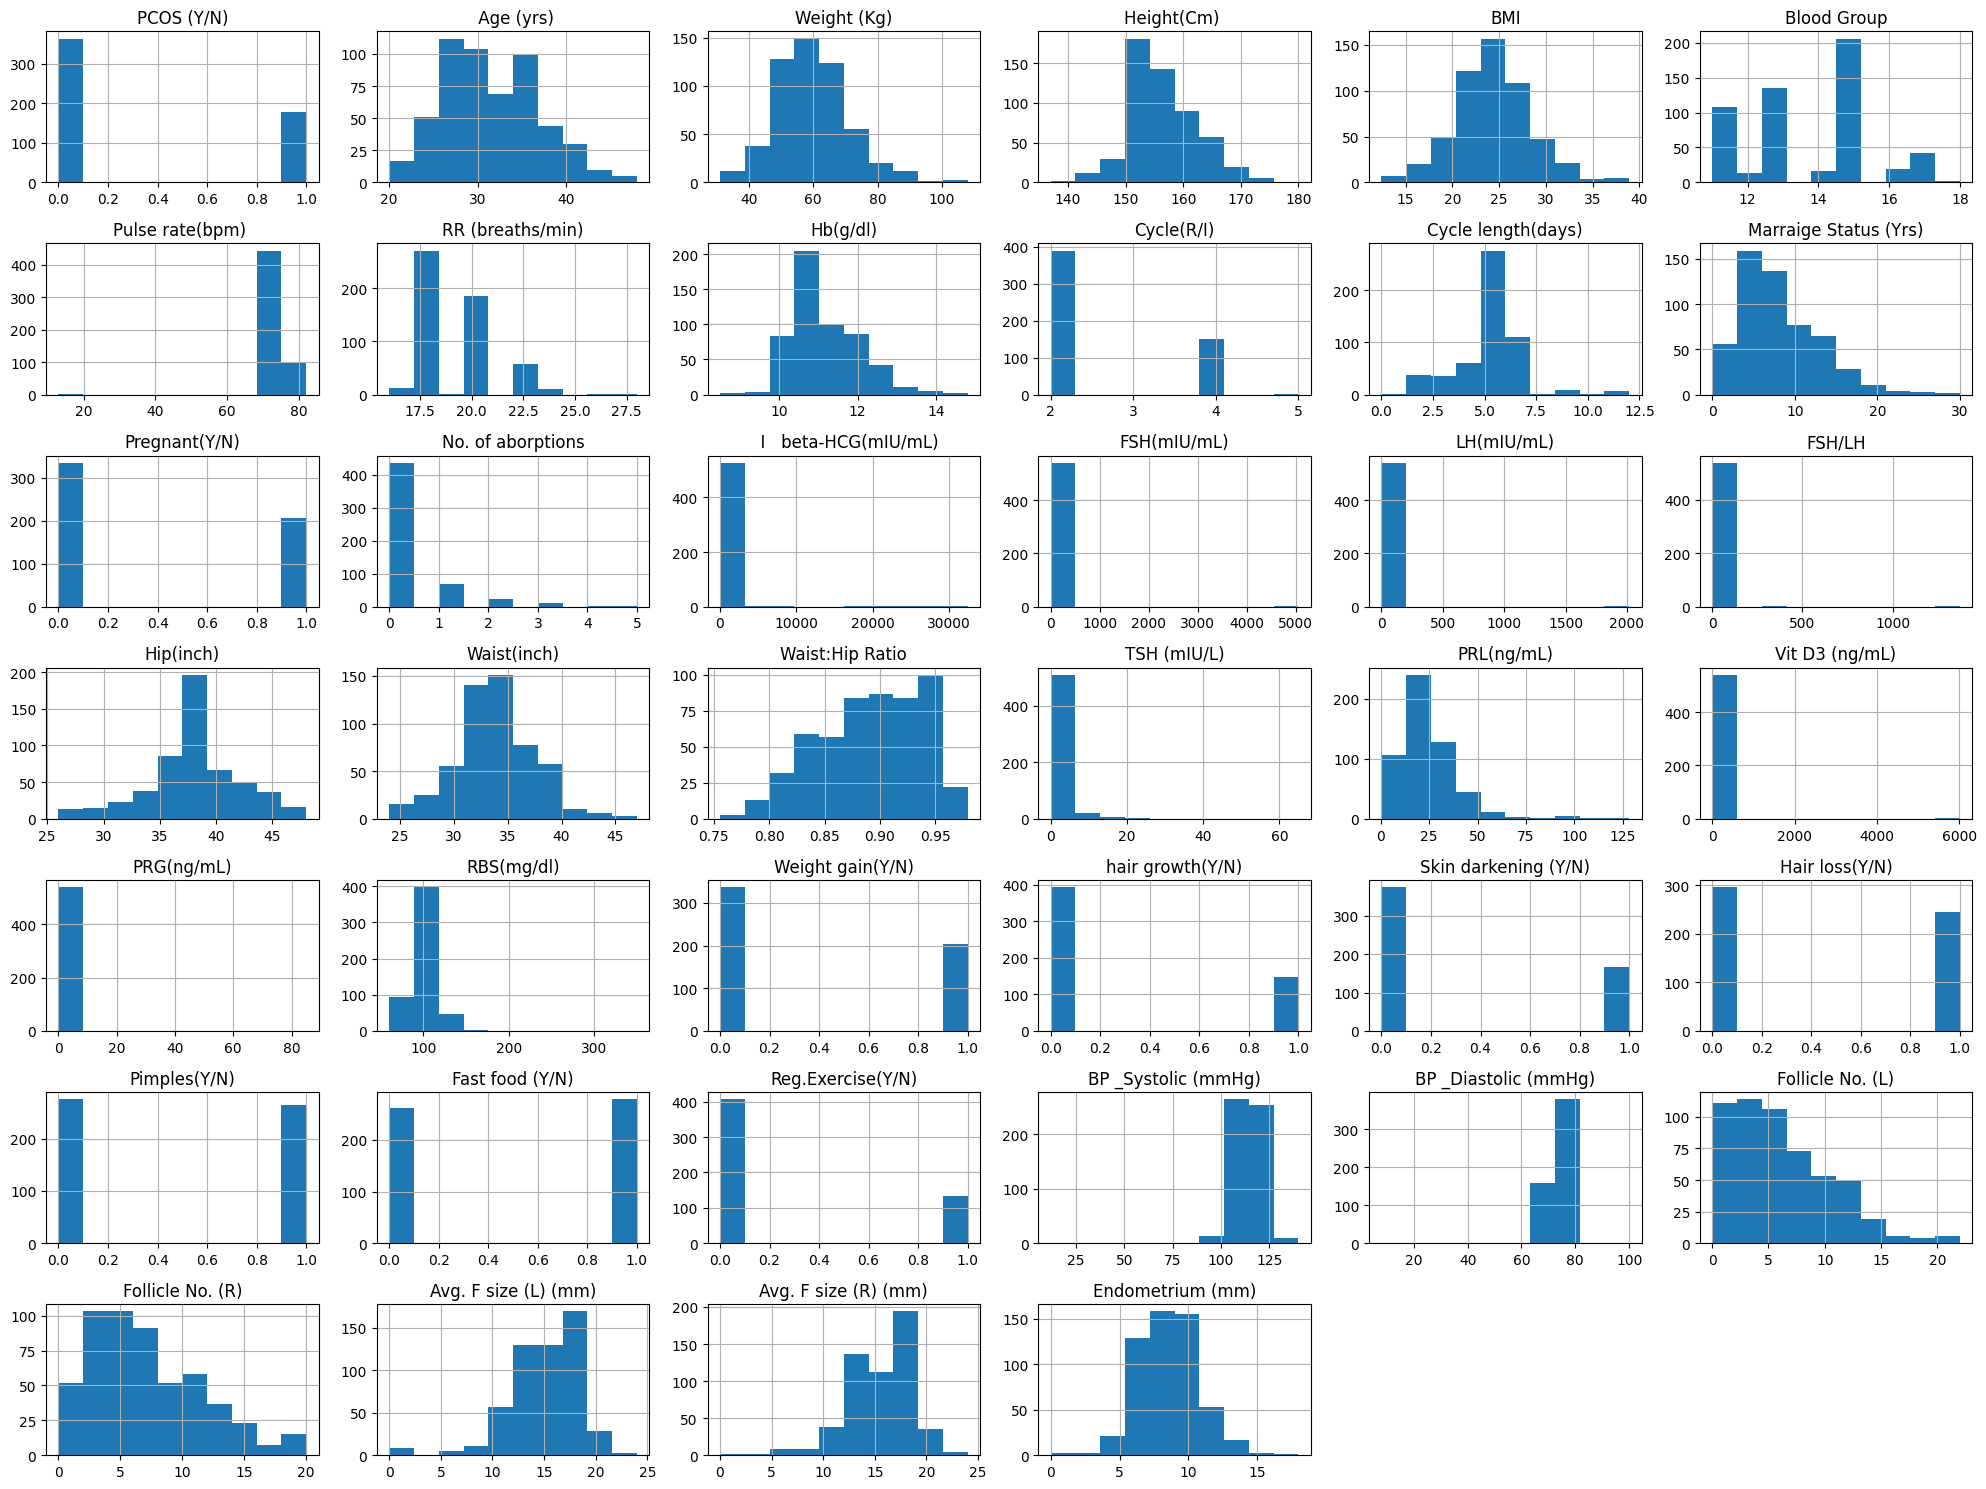

In [ ]:
import matplotlib.pyplot as plt

df.hist(figsize=(20,15))
plt.tight_layout()
plt.show()

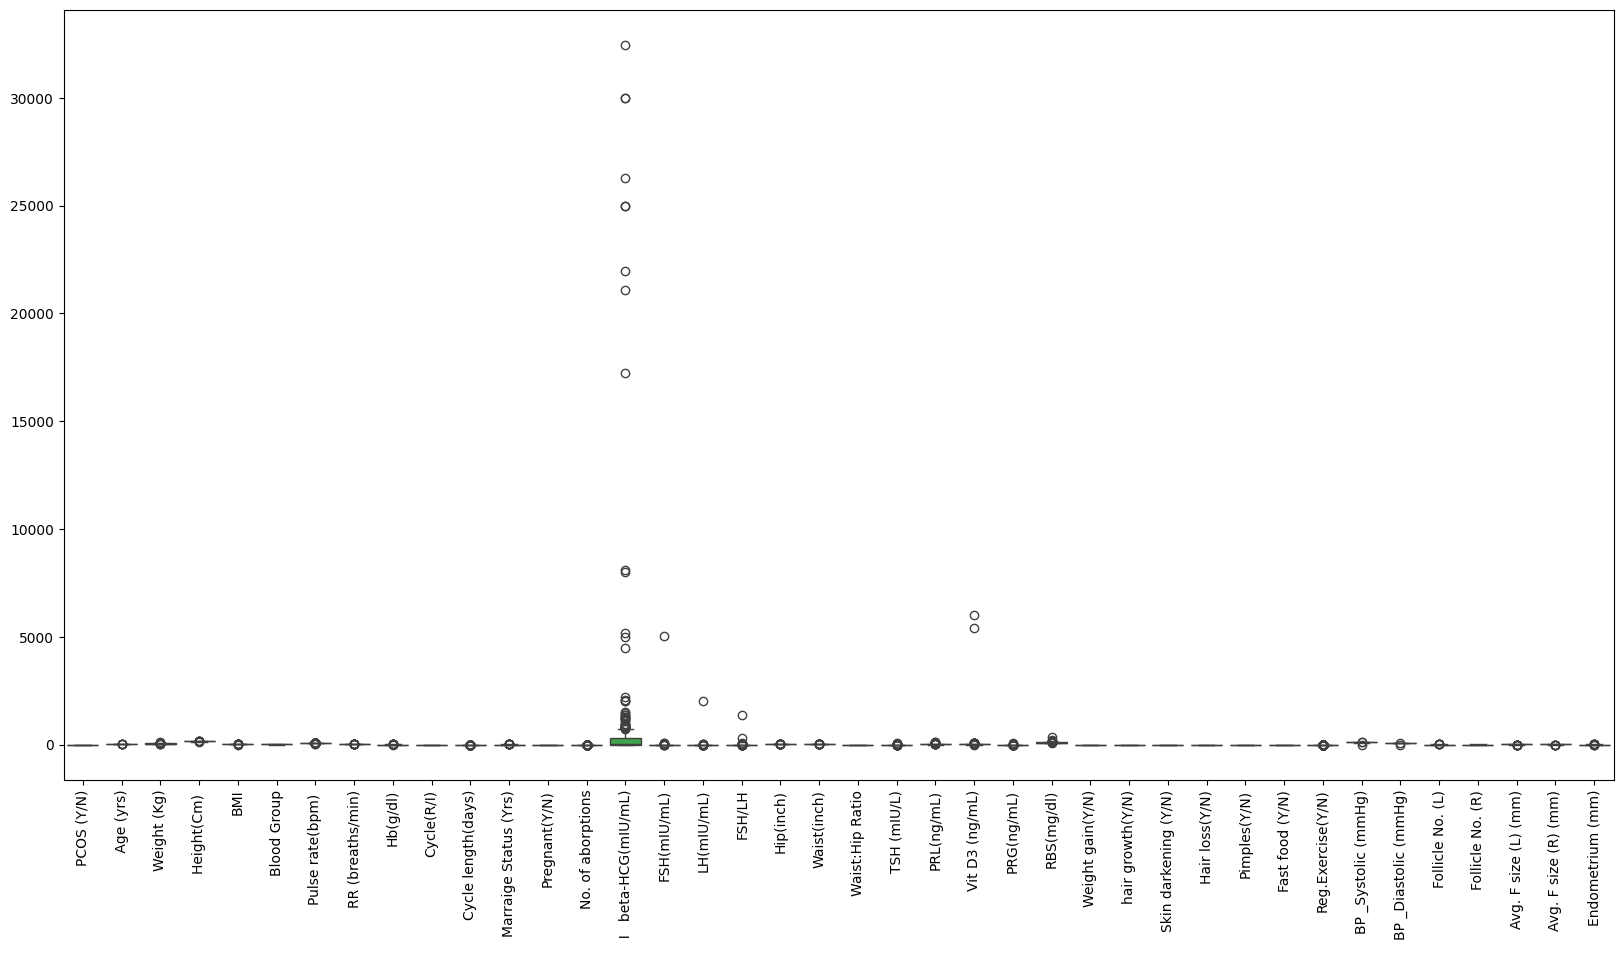

In [ ]:
import seaborn as sns

plt.figure(figsize=(20,10))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.xticks(rotation=90)
plt.show()

In [ ]:
continuous_cols = [
    col for col in df.select_dtypes(include=['int64', 'float64']).columns
    if df[col].nunique() > 10
]

df_cont = df[continuous_cols]

Q1 = df_cont.quantile(0.25)
Q3 = df_cont.quantile(0.75)
IQR = Q3 - Q1

In [ ]:
symptom_cols = [
    'Weight gain(Y/N)',
    'hair growth(Y/N)',
    'Skin darkening (Y/N)',
    'Hair loss(Y/N)',
    'Pimples(Y/N)',
    'Fast food (Y/N)',
    'Reg.Exercise(Y/N)'
]

df[symptom_cols].head()

,Weight gain(Y/N),hair growth(Y/N),Skin darkening (Y/N),Hair loss(Y/N),Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N)
0,0,0,0,0,0,1.0,0
1,0,0,0,0,0,0.0,0
2,0,0,0,1,1,1.0,0
3,0,0,0,0,0,0.0,0
4,0,0,0,1,0,0.0,0


In [ ]:
df['Fast food (Y/N)'] = df['Fast food (Y/N)'].astype(int)

In [ ]:
cols_problematicas = ['II    beta-HCG(mIU/mL)', 'AMH(ng/mL)']

for col in cols_problematicas:
    # Convertir a string
    df[col] = df[col].astype(str)

    # Quitar caracteres raros (dejando solo números y punto)
    df[col] = df[col].str.replace(r'[^\d.]', '', regex=True)

    # Arreglar casos como "1.99." → "1.99"
    df[col] = df[col].str.rstrip('.')

    # Convertir a float
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [ ]:
for col in cols_problematicas:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_1435/3513857292.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


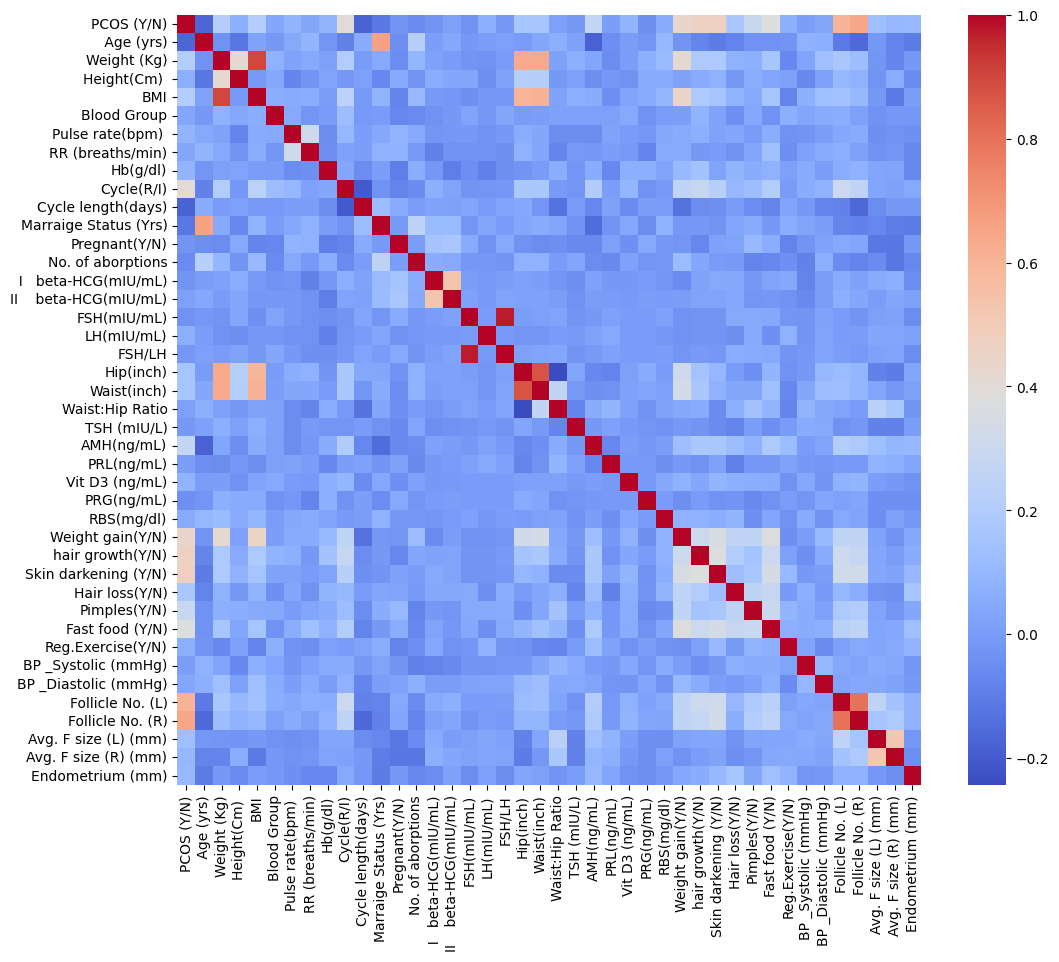

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.show()

In [ ]:
corr_target = df.corr()['PCOS (Y/N)'].sort_values(ascending=False)
corr_target

,PCOS (Y/N)
PCOS (Y/N),1.000000
Follicle No. (R),0.648327
Follicle No. (L),0.603346
Skin darkening (Y/N),0.475733
hair growth(Y/N),0.464667
Weight gain(Y/N),0.441047
Cycle(R/I),0.401644
Fast food (Y/N),0.376183
Pimples(Y/N),0.286077
AMH(ng/mL),0.264141


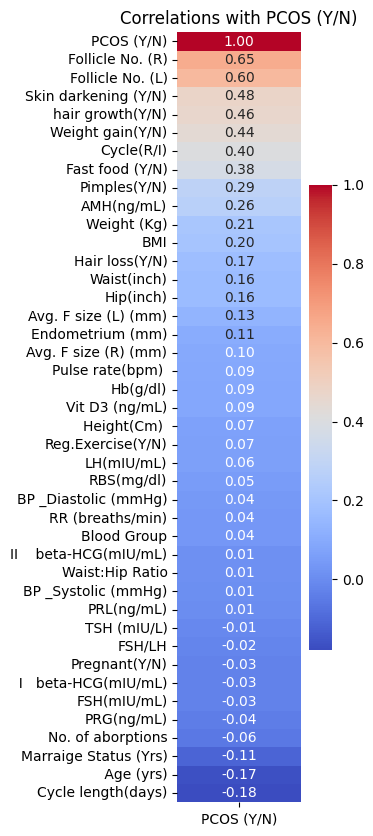

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert the Series to a DataFrame with a single column
corr_target_df = corr_target.to_frame()

plt.figure(figsize=(2, 10)) # Adjust figsize for a single column heatmap
sns.heatmap(corr_target_df, cmap='coolwarm', annot=True, fmt=".2f", cbar=True)
plt.title('Correlations with PCOS (Y/N)')
plt.yticks(rotation=0) # Ensure y-axis labels are horizontal for readability
plt.show()

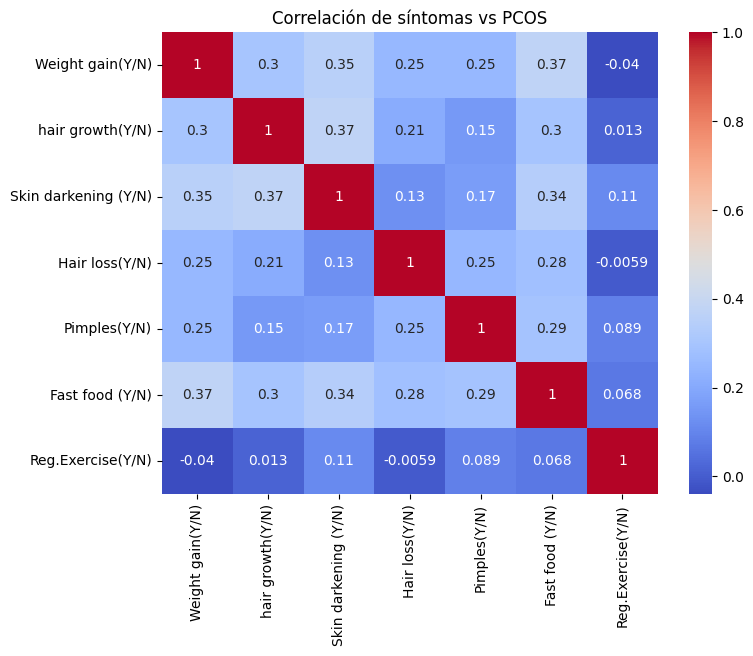

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df[symptom_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlación de síntomas vs PCOS")
plt.show()

In [ ]:
# Convertir Y/N a 1/0
df = df.replace({'Y': 1, 'N': 0})

# Asegurar que AMH y folículos sean numéricos
cols_clinicas = ['AMH(ng/mL)', 'Follicle No. (R)', 'Follicle No. (L)']

for col in cols_clinicas:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Rellenar NaN por seguridad
df[cols_clinicas] = df[cols_clinicas].fillna(df[cols_clinicas].median())

In [ ]:
target_cols_clinicas = [
    'AMH(ng/mL)',
    'Follicle No. (R)',
    'Follicle No. (L)'
]

cols = symptom_cols + target_cols_clinicas
df_corr_clinica_sintomas = df[cols]

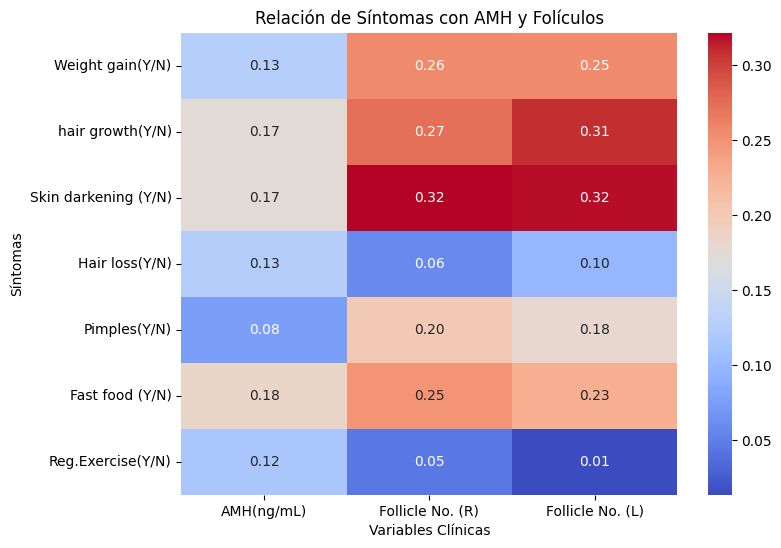

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df_corr_clinica_sintomas.corr().loc[symptom_cols, target_cols_clinicas],
    annot=True,
    cmap='coolwarm',
    fmt=".2f"
)

plt.title("Relación de Síntomas con AMH y Folículos")
plt.xlabel("Variables Clínicas")
plt.ylabel("Síntomas")
plt.show()